<a href="https://colab.research.google.com/github/ghizlane89/0__GenIA/blob/Bootcamp/W7_D1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
train_df = pd.read_csv('/content/drive/MyDrive/Datasets/train_W7.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Datasets/test_W7.csv')

Mounted at /content/drive


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5195 entries, 0 to 5194
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5195 non-null   object
 1   premise     5195 non-null   object
 2   hypothesis  5195 non-null   object
 3   lang_abv    5195 non-null   object
 4   language    5195 non-null   object
dtypes: object(5)
memory usage: 203.1+ KB


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          12120 non-null  object
 1   premise     12120 non-null  object
 2   hypothesis  12120 non-null  object
 3   lang_abv    12120 non-null  object
 4   language    12120 non-null  object
 5   label       12120 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 568.3+ KB


In [ ]:
# -----------------------------------------------------------
# 📦 1. Importation des bibliothèques nécessaires
# -----------------------------------------------------------
import pandas as pd
from transformers import BertTokenizer, XLMRobertaTokenizer
from sklearn.model_selection import StratifiedKFold

# -----------------------------------------------------------
# 📁 2. Chargement des datasets d'entraînement et de test
# -----------------------------------------------------------
train_path = "/content/drive/MyDrive/Datasets/train_W7.csv"
test_path = "/content/drive/MyDrive/Datasets/test_W7.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# -----------------------------------------------------------
# 📊 3. Exploration rapide des données
# -----------------------------------------------------------
print("🔍 Données d'entraînement :")
print("Colonnes :", train_df.columns.tolist())
print(train_df.head())
print("Taille :", train_df.shape)

print("\n🔍 Données de test :")
print("Colonnes :", test_df.columns.tolist())
print(test_df.head())
print("Taille :", test_df.shape)

# -----------------------------------------------------------
# 🧠 4. Initialisation des tokenizers pour BERT et XLM-RoBERTa
# -----------------------------------------------------------
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

# -----------------------------------------------------------
# 🔡 5. Tokenisation d’une paire de phrases exemple issue de train_df
# -----------------------------------------------------------
premise = train_df.loc[0, 'premise']
hypothesis = train_df.loc[0, 'hypothesis']

bert_encoded = bert_tokenizer.encode_plus(
    premise,
    hypothesis,
    max_length=64,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

xlmr_encoded = xlmr_tokenizer.encode_plus(
    premise,
    hypothesis,
    max_length=64,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

# -----------------------------------------------------------
# 📎 6. Affichage des résultats de la tokenisation
# -----------------------------------------------------------
print("\n🧾 Exemple BERT :")
print("input_ids :", bert_encoded['input_ids'])
print("attention_mask :", bert_encoded['attention_mask'])
print("Texte reconstruit :", bert_tokenizer.decode(bert_encoded['input_ids'][0]))

print("\n🧾 Exemple XLM-R :")
print("input_ids :", xlmr_encoded['input_ids'])
print("attention_mask :", xlmr_encoded['attention_mask'])
print("Texte reconstruit :", xlmr_tokenizer.decode(xlmr_encoded['input_ids'][0]))

# -----------------------------------------------------------
# 🧩 7. Informations sur les tokens spéciaux et tailles de vocabulaires
# -----------------------------------------------------------
print("\n📚 BERT - Tokens spéciaux :", bert_tokenizer.special_tokens_map)
print("📚 BERT - Taille vocabulaire :", bert_tokenizer.vocab_size)
print("📚 XLM-R - Tokens spéciaux :", xlmr_tokenizer.special_tokens_map)
print("📚 XLM-R - Taille vocabulaire :", xlmr_tokenizer.vocab_size)

# -----------------------------------------------------------
# 🔁 8. Création des folds pour un entraînement croisé (StratifiedKFold)
# -----------------------------------------------------------
labels = train_df['label']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_indices_list = []
val_indices_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, labels)):
    train_indices_list.append(train_idx)
    val_indices_list.append(val_idx)
    print(f"\n🌀 Fold {fold + 1} :")
    print("Train indices :", train_idx[:5])
    print("Val indices :", val_idx[:5])

# -----------------------------------------------------------
# 🚀 9. Tokenisation des données de test pour préparation à l’inférence
# -----------------------------------------------------------
print("\n🚀 Tokenisation sur test_df (premières lignes) :")
for i in range(3):  # ↪ Modifier selon le nombre de lignes à traiter
    p = test_df.loc[i, 'premise']
    h = test_df.loc[i, 'hypothesis']
    encoded = xlmr_tokenizer.encode_plus(
        p,
        h,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_attention_mask=True
    )
    print(f"\n📎 Ligne {i} - input_ids :", encoded['input_ids'])
    print(f"📎 Ligne {i} - attention_mask :", encoded['attention_mask'])


🔍 Données d'entraînement :
Colonnes : ['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label']
           id                                            premise  \
0  5130fd2cb5  and these comments were considered in formulat...   
1  5b72532a0b  These are issues that we wrestle with in pract...   
2  3931fbe82a  Des petites choses comme celles-là font une di...   
3  5622f0c60b  you know they can't really defend themselves l...   
4  86aaa48b45  ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...   

                                          hypothesis lang_abv language  label  
0  The rules developed in the interim were put to...       en  English      0  
1  Practice groups are not permitted to work on t...       en  English      2  
2              J'essayais d'accomplir quelque chose.       fr   French      0  
3  They can't defend themselves because of their ...       en  English      0  
4    เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร       th     Thai      1  
Taille :

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.



🧾 Exemple BERT :
input_ids : tensor([[ 101, 1998, 2122, 7928, 2020, 2641, 1999, 5675, 3436, 1996, 9455, 3513,
         1012,  102, 1996, 3513, 2764, 1999, 1996, 9455, 2020, 2404, 2362, 2007,
         2122, 7928, 1999, 2568, 1012,  102,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]])
attention_mask : tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Texte reconstruit : [CLS] and these comments were considered in formulating the interim rules. [SEP] the rules developed in the interim were put together with these comments in mind. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [

🔍 Jeu de données d’entraînement et de test
📂 train_df

Contient 12 120 échantillons répartis sur 6 colonnes : premise, hypothesis, lang_abv, language, label, etc.

La colonne label regroupe des valeurs numériques (0, 1, 2) correspondant probablement à une tâche de classification NLI (Natural Language Inference).

Interprétation probable des labels :

0 → contradiction

1 → neutre

2 → implication (entailment)

Objectif possible : entraîner un modèle à prédire le label à partir d’un couple (premise, hypothesis).

📂 test_df

Contient 5 195 échantillons répartis sur 5 colonnes (sans colonne label).

Langues variées : Urdu, Arabe, Chinois, Russe, etc.

Destiné à la phase d’inférence : le modèle doit prédire les labels inconnus.

🧾 Exemple de tokenisation — BERT vs XLM-RoBERTa
🔹 BERT

Utilise des tokens spéciaux : [CLS] (début de séquence) et [SEP] (séparateur entre phrases).

input_ids : identifiants numériques des tokens.

attention_mask :

1 → vrai token

0 → padding [PAD]

Exemple :

30 tokens utiles → marqués 1

34 tokens de padding → marqués 0

Séquence reconstruite : [CLS] ... [SEP] ... [SEP] [PAD] [PAD] ...

C’est une représentation standard pour l’entraînement et l’inférence.

==> Prise en compte des questions

Dimensions du train set : (12120, 6)
Dimensions du test set : (5195, 5)
Répartition des classes : label
0    4176
2    4064
1    3880
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


🌟 Fold 1
Epoch 1 ➤ Train Loss: 1.0375 | Val Loss: 0.8941 | Val Acc: 0.5982
Epoch 2 ➤ Train Loss: 0.8231 | Val Loss: 0.8430 | Val Acc: 0.6200
Epoch 3 ➤ Train Loss: 0.5967 | Val Loss: 0.9474 | Val Acc: 0.6048

🌟 Fold 2
Epoch 1 ➤ Train Loss: 0.5420 | Val Loss: 0.3326 | Val Acc: 0.8762
Epoch 2 ➤ Train Loss: 0.3321 | Val Loss: 0.3636 | Val Acc: 0.8692
Epoch 3 ➤ Train Loss: 0.1956 | Val Loss: 0.3827 | Val Acc: 0.8700

🌟 Fold 3
Epoch 1 ➤ Train Loss: 0.2251 | Val Loss: 0.0439 | Val Acc: 0.9884
Epoch 2 ➤ Train Loss: 0.1389 | Val Loss: 0.0629 | Val Acc: 0.9773
Epoch 3 ➤ Train Loss: 0.0927 | Val Loss: 0.0761 | Val Acc: 0.9757

🌟 Fold 4
Epoch 1 ➤ Train Loss: 0.1052 | Val Loss: 0.0312 | Val Acc: 0.9901
Epoch 2 ➤ Train Loss: 0.0775 | Val Loss: 0.0336 | Val Acc: 0.9901
Epoch 3 ➤ Train Loss: 0.0619 | Val Loss: 0.0460 | Val Acc: 0.9851

🌟 Fold 5
Epoch 1 ➤ Train Loss: 0.0714 | Val Loss: 0.0069 | Val Acc: 0.9975
Epoch 2 ➤ Train Loss: 0.0588 | Val Loss: 0.0171 | Val Acc: 0.9955
Epoch 3 ➤ Train Loss: 0.05

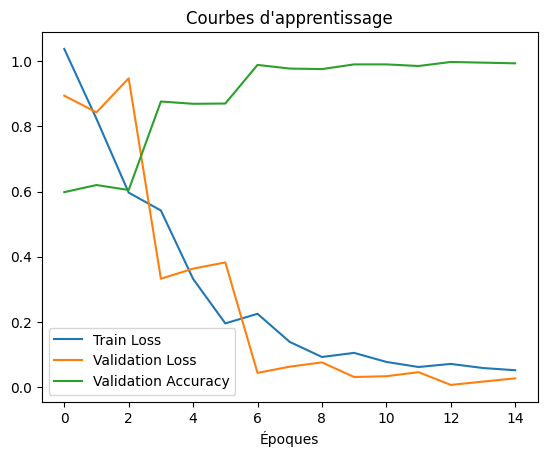

✅ Fichier 'submission.csv' généré.


In [ ]:
# ------------------------------------------------------------
# 📂 ÉTAPE 1 — IMPORTS ET CHARGEMENT DES DONNÉES
# ------------------------------------------------------------
# On importe toutes les bibliothèques nécessaires :
# - pandas pour manipuler les données
# - torch pour le deep learning
# - transformers pour utiliser BERT
# - sklearn pour le découpage stratifié
# - matplotlib & numpy pour la visualisation et les calculs
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 📥 Chargement des fichiers CSV d'entraînement et de test
train_df = pd.read_csv("/content/drive/MyDrive/Datasets/train_W7.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Datasets/test_W7.csv")

# 📊 Aperçu rapide des données
print("Dimensions du train set :", train_df.shape)
print("Dimensions du test set :", test_df.shape)
print("Répartition des classes :", train_df['label'].value_counts())

# ------------------------------------------------------------
# ✂️ ÉTAPE 2 — TOKENISATION AVEC BERT MULTILINGUE
# ------------------------------------------------------------
# On utilise le tokenizer de BERT pour transformer texte → tokens
# Chaque paire (premise, hypothesis) est encodée avec masques d’attention
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def bert_encode(premises, hypotheses, tokenizer, max_len=64):
    input_ids = []
    attention_masks = []

    for p, h in zip(premises, hypotheses):
        encoded = tokenizer.encode_plus(
            p, h,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    return torch.tensor(input_ids), torch.tensor(attention_masks)

# 🔄 Encodage du jeu d’entraînement
X_input_ids, X_attention_masks = bert_encode(train_df['premise'], train_df['hypothesis'], tokenizer)
y_labels = torch.tensor(train_df['label'].values)

# 🔄 Encodage du jeu de test
test_input_ids, test_attention_masks = bert_encode(test_df['premise'], test_df['hypothesis'], tokenizer)

# ------------------------------------------------------------
# 🏗️ ÉTAPE 3 — CONSTRUCTION DU MODÈLE
# ------------------------------------------------------------
# Architecture : BERT + Dropout + Couche de classification
class BERTClassifier(nn.Module):
    def __init__(self):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 3)  # 3 classes

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output  # Récupère le vecteur [CLS]
        x = self.dropout(cls_output)
        return self.classifier(x)

model = BERTClassifier()

# ------------------------------------------------------------
# ⚙️ ÉTAPE 4 — PRÉPARATION À L'ENTRAÎNEMENT
# ------------------------------------------------------------
# - Définition de la fonction de perte
# - Configuration de l’optimiseur Adam
# - Envoi du modèle sur GPU si dispo
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 📐 Création des folds pour validation croisée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses, val_losses, val_accuracies = [], [], []

# ------------------------------------------------------------
# 🔄 ENTRAÎNEMENT AVEC VALIDATION CROISÉE
# ------------------------------------------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X_input_ids, y_labels)):
    print(f"\n🌟 Fold {fold + 1}")

    # 📦 Création des DataLoaders
    train_dataset = TensorDataset(X_input_ids[train_idx], X_attention_masks[train_idx], y_labels[train_idx])
    val_dataset = TensorDataset(X_input_ids[val_idx], X_attention_masks[val_idx], y_labels[val_idx])

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)

    # --------------------------------------------------------
    # 🔁 BOUCLE D'APPRENTISSAGE
    # --------------------------------------------------------
    epochs = 3
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # 📚 Entraînement
        for batch in train_loader:
            b_input_ids, b_att_mask, b_labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            outputs = model(b_input_ids, b_att_mask)
            loss = criterion(outputs, b_labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # 📊 Validation
        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_att_mask, b_labels = [x.to(device) for x in batch]
                outputs = model(b_input_ids, b_att_mask)
                loss = criterion(outputs, b_labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += torch.sum(preds == b_labels)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct.item() / len(val_idx)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1} ➤ Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ------------------------------------------------------------
# 📉 ÉTAPE 6 — VISUALISATION DES COURBES
# ------------------------------------------------------------
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Courbes d'apprentissage")
plt.xlabel("Époques")
plt.show()

# ------------------------------------------------------------
# 🧪 ÉTAPE 7 — PRÉDICTION SUR LE TEST SET
# ------------------------------------------------------------
model.eval()
test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_loader = DataLoader(test_dataset, batch_size=16)

all_preds = []
with torch.no_grad():
    for batch in test_loader:
        b_input_ids, b_att_mask = [x.to(device) for x in batch]
        outputs = model(b_input_ids, b_att_mask)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())

# 💾 Génération du fichier de soumission
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'label': all_preds
})
submission_df.to_csv("submission.csv", index=False)
print("✅ Fichier 'submission.csv' généré.")
